Setup, load and preprocess data

In [ ]:
# Setup: load and preprocess data so later sections work

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the cleaned CSV
data = pd.read_csv('/content/housesdata.csv', header=None)

# 2. Rename columns
data.columns = [
    'ID',
    'Property_Name',
    'Price',
    'House_Type',
    'Area_sqft',
    'Bedrooms',
    'Bathrooms',
    'Receptions',
    'Location',
    'City_County',
    'Postal_Code']

# 3. Replace '?' with NaN
data = data.replace('?', np.nan)

# 4. Convert numeric columns
numeric_cols = ['Price', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Receptions']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 5. Fill missing values
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

# Drop high-cardinality / useless columns
data = data.drop(columns=['Property_Name', 'Postal_Code', 'Location'])

# 6. Categorical columns we keep
categorical_cols = ['House_Type', 'City_County']

# 7. One-hot encode
data_encoded = pd.get_dummies(
    data,
    columns=categorical_cols,
    drop_first=True)

# 8. Scale numeric features
scaler = StandardScaler()
data_encoded[numeric_cols] = scaler.fit_transform(data_encoded[numeric_cols])

# 9. Train–test split
X = data_encoded.drop(['ID', 'Price'], axis=1)
y = data_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Setup complete.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('/content/housesdata.csv')

print(data.head(10))
print("Shape:", data.shape)
print(data.dtypes)

#print(data.head())
#print(data.shape)


    0          Queens Road  1675000             House  2716  5  5.1  5.2  \
0   1        Seward Street   650000  Flat / Apartment   814  2    2    2   
1   2          Hotham Road   735000  Flat / Apartment   761  2    2    2   
2   3         Festing Road  1765000             House  1986  4    4    4   
3   4         Spencer Walk   675000  Flat / Apartment   700  2    2    2   
4   5  Craven Hill Gardens   420000  Flat / Apartment   403  1    1    1   
5   6       Alfriston Road  1475000             House  1548  4    4    4   
6   7         Bishops Gate   650000   New development   560  1    1    1   
7   8       Adam  Eve Mews  2500000             House  1308  3    3    3   
8   9       Hornton Street   925000  Flat / Apartment   646  2    2    2   
9  10      Drakefield Road  2400000             House  3392  6    6    6   

     Wimbledon  London  SW19 8NY  
0  Clerkenwell  London  EC1V 3PA  
1       Putney  London  SW15 1QL  
2       Putney  London  SW15 1LP  
3       Putney  London 

Initial data analysis

In [ ]:
print("First 10 rows:\n", data.head(10))
print("\nShape:", data.shape)
print("\nColumn names:", data.columns.tolist())
print("\nData types:\n", data.dtypes)
print("\nMissing values:\n", data.isna().sum())

First 10 rows:
     0          Queens Road  1675000             House  2716  5  5.1  5.2  \
0   1        Seward Street   650000  Flat / Apartment   814  2    2    2   
1   2          Hotham Road   735000  Flat / Apartment   761  2    2    2   
2   3         Festing Road  1765000             House  1986  4    4    4   
3   4         Spencer Walk   675000  Flat / Apartment   700  2    2    2   
4   5  Craven Hill Gardens   420000  Flat / Apartment   403  1    1    1   
5   6       Alfriston Road  1475000             House  1548  4    4    4   
6   7         Bishops Gate   650000   New development   560  1    1    1   
7   8       Adam  Eve Mews  2500000             House  1308  3    3    3   
8   9       Hornton Street   925000  Flat / Apartment   646  2    2    2   
9  10      Drakefield Road  2400000             House  3392  6    6    6   

     Wimbledon  London  SW19 8NY  
0  Clerkenwell  London  EC1V 3PA  
1       Putney  London  SW15 1QL  
2       Putney  London  SW15 1LP  
3      

Data pre-processing

Nameing the columns

In [ ]:
data.columns = [
    'ID',
    'Property_Name',
    'Price',
    'House_Type',
    'Area_sqft',
    'Bedrooms',
    'Bathrooms',
    'Receptions',
    'Location',
    'City_County',
    'Postal_Code']

data.head()


,ID,Property_Name,Price,House_Type,Area_sqft,Bedrooms,Bathrooms,Receptions,Location,City_County,Postal_Code
0,1,Seward Street,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London,EC1V 3PA
1,2,Hotham Road,735000,Flat / Apartment,761,2,2,2,Putney,London,SW15 1QL
2,3,Festing Road,1765000,House,1986,4,4,4,Putney,London,SW15 1LP
3,4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,Putney,London,SW15 1PL
4,5,Craven Hill Gardens,420000,Flat / Apartment,403,1,1,1,?,London,W2 3EA


Replacing the '?' with proper missing values (NaN)

In [ ]:
import numpy as np

data = data.replace('?', np.nan)
data.isna().sum()


,0
ID,0
Property_Name,0
Price,0
House_Type,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Receptions,0
Location,962
City_County,0


Converting numeric columns to numeric types

In [ ]:
numeric_cols = ['Price', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Receptions']

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data[numeric_cols].dtypes


,0
Price,int64
Area_sqft,int64
Bedrooms,int64
Bathrooms,int64
Receptions,int64


Handling the missing values

In [ ]:
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

categorical_cols = ['House_Type', 'Location', 'City_County', 'Postal_Code']

for col in categorical_cols:
    data[col] = data[col].fillna('Unknown')


One-hot encoding the categorical variables

In [ ]:
data_encoded = pd.get_dummies(
    data,
    columns=categorical_cols,
    drop_first=True)  # To avoid dummy variables

data_encoded.head()

,ID,Property_Name,Price,Area_sqft,Bedrooms,Bathrooms,Receptions,House_Type_Duplex,House_Type_Flat / Apartment,House_Type_House,...,Postal_Code_WD19 4PL,Postal_Code_WD19 4PU,Postal_Code_WD19 4QG,Postal_Code_WD19 4QQ,Postal_Code_WD19 4TR,Postal_Code_WD19 4TS,Postal_Code_WD23 2RG,Postal_Code_WD23 2RH,Postal_Code_WD23 3EW,Postal_Code_WD7 9HJ
0,1,Seward Street,650000,814,2,2,2,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2,Hotham Road,735000,761,2,2,2,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,3,Festing Road,1765000,1986,4,4,4,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,4,Spencer Walk,675000,700,2,2,2,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,5,Craven Hill Gardens,420000,403,1,1,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False


Removing the irrelevant categorical features

In [ ]:
data = data.drop(columns=['Property_Name', 'Postal_Code', 'Location'])
data.head()

,ID,Price,House_Type,Area_sqft,Bedrooms,Bathrooms,Receptions,City_County
0,1,650000,Flat / Apartment,814,2,2,2,London
1,2,735000,Flat / Apartment,761,2,2,2,London
2,3,1765000,House,1986,4,4,4,London
3,4,675000,Flat / Apartment,700,2,2,2,London
4,5,420000,Flat / Apartment,403,1,1,1,London


One-hot encoding the City_County

In [ ]:
categorical_cols = ['House_Type', 'City_County']

data_encoded = pd.get_dummies(
    data,
    columns=categorical_cols,
    drop_first=True)

data_encoded.head()


,ID,Price,Area_sqft,Bedrooms,Bathrooms,Receptions,House_Type_Duplex,House_Type_Flat / Apartment,House_Type_House,House_Type_Mews,...,City_County_Surrey,City_County_Surrey Quays,City_County_Thames Ditton,City_County_The Metal Works,City_County_Thurleigh Road,City_County_Twickenham,City_County_Wandsworth,City_County_Watford,City_County_Wimbledon,City_County_Wornington Road
0,1,650000,814,2,2,2,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,735000,761,2,2,2,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1765000,1986,4,4,4,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,4,675000,700,2,2,2,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,420000,403,1,1,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


Scaling the numeric features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_encoded[numeric_cols] = scaler.fit_transform(data_encoded[numeric_cols])

data_encoded[numeric_cols].head()

,Price,Area_sqft,Bedrooms,Bathrooms,Receptions
0,-0.535543,-0.658786,-0.727047,-0.727047,-0.727047
1,-0.498053,-0.697638,-0.727047,-0.727047,-0.727047
2,-0.043765,0.200355,0.591034,0.591034,0.591034
3,-0.524517,-0.742354,-0.727047,-0.727047,-0.727047
4,-0.636986,-0.960072,-1.386088,-1.386088,-1.386088


Spliting the data into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

X = data_encoded.drop(['ID', 'Price'], axis=1)
y = data_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape


((2783, 67), (696, 67))

Post pre-processing data analysis

Summary of Statistics

In [ ]:
numeric_cols = ['Price', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Receptions']
data[numeric_cols].describe()

,Price,Area_sqft,Bedrooms,Bathrooms,Receptions
count,3.479000e+03,3479.000000,3479.000000,3479.000000,3479.000000
mean,1.864227e+06,1712.685254,3.103191,3.103191,3.103191
std,2.267607e+06,1364.349430,1.517575,1.517575,1.517575
min,1.800000e+05,274.000000,0.000000,0.000000,0.000000
25%,7.500000e+05,834.000000,2.000000,2.000000,2.000000
50%,1.215000e+06,1310.000000,3.000000,3.000000,3.000000
75%,2.150000e+06,2156.500000,4.000000,4.000000,4.000000
max,3.975000e+07,15405.000000,10.000000,10.000000,10.000000


Generating histograms

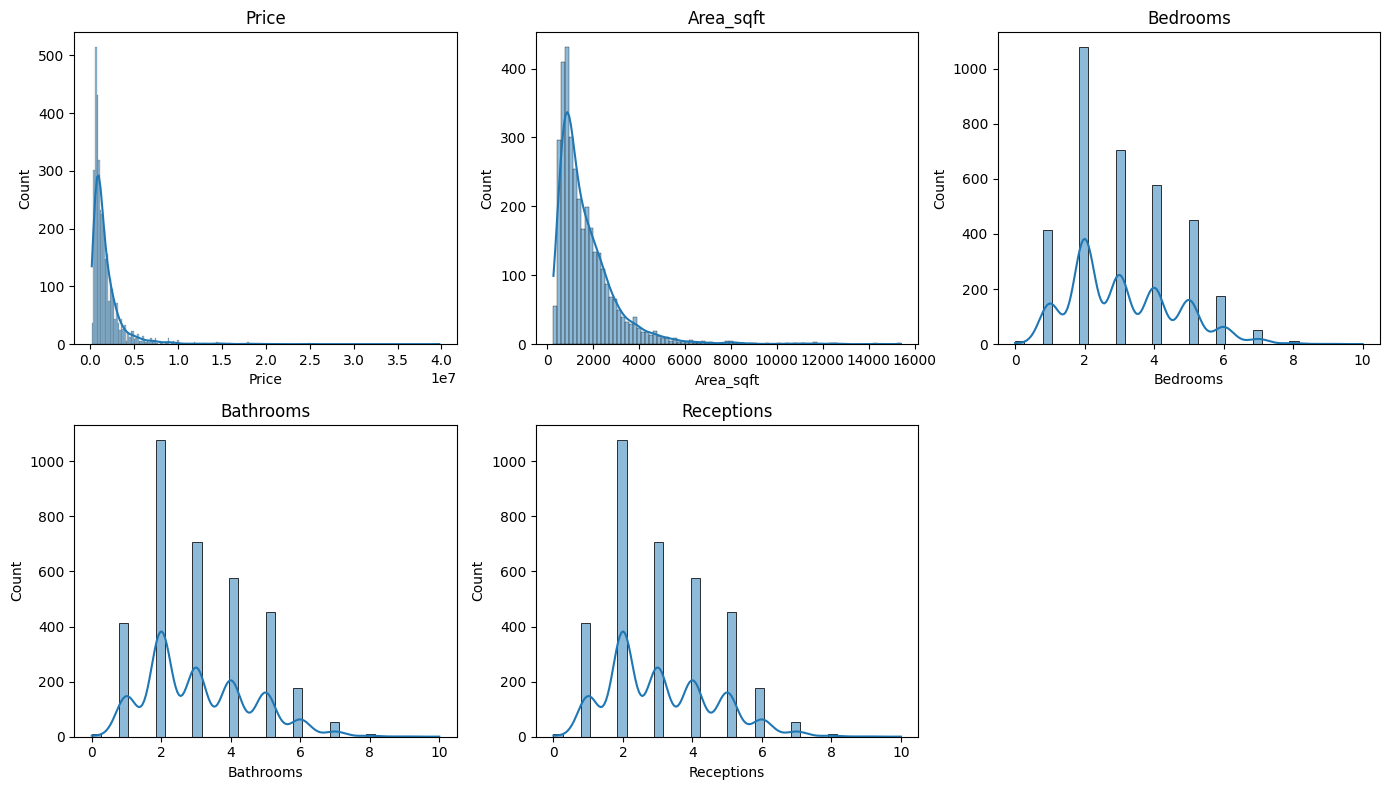

In [ ]:
plt.figure(figsize=(14,8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(data[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Generating boxplots

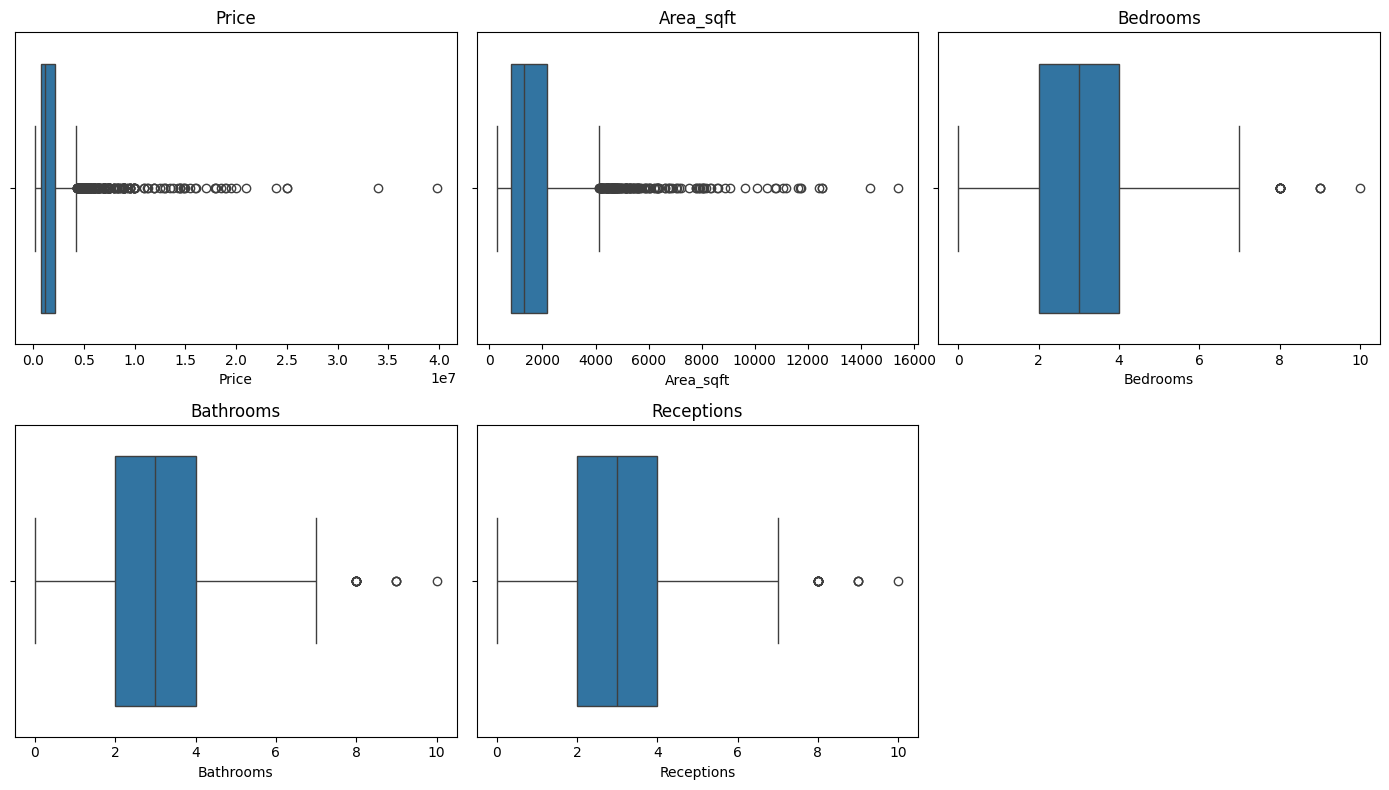

In [ ]:
plt.figure(figsize=(14,8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Correlation Heatmap

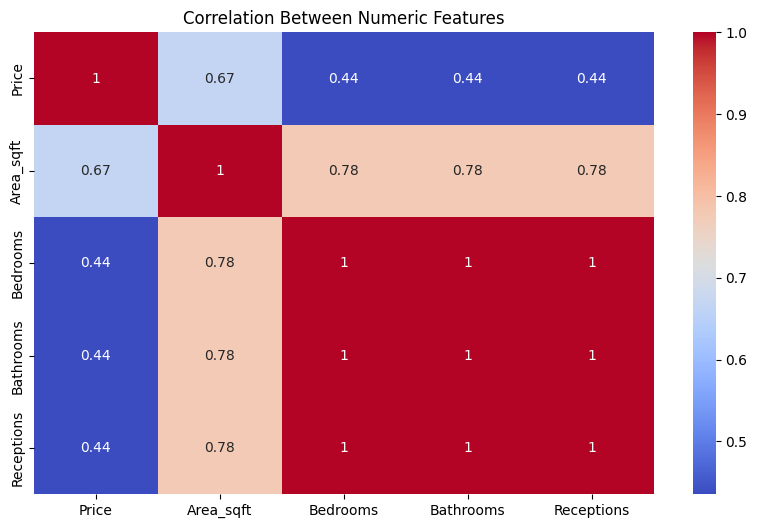

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()

Linear regression

Training the model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Creating and train the model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Predicting using the test set
y_pred_lin = lin_model.predict(X_test)

Evaluating the model

In [ ]:
# Evaluation metrics
mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

mae_lin, mse_lin, rmse_lin, r2_lin

(0.3192151292171784,
 0.5914878541209088,
 np.float64(0.7690824754998054),
 0.4500736120113885)

Elastic net regression

Training the model

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Creating the Elastic Net model
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)

# Training the model
elastic_model.fit(X_train, y_train)

# Predicting using the test set
y_pred_elastic = elastic_model.predict(X_test)

Evaluating the model

In [ ]:
# Evaluation metrics
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)

mae_elastic, mse_elastic, rmse_elastic, r2_elastic

(0.3319972203415491,
 0.3799941502720928,
 np.float64(0.6164366555227656),
 0.3878679787917594)

Tuning the model to achieve better performance

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet

# Defining the parameter grid for Elastic Net
param_grid_elastic = {
    'alpha': [0.01, 0.1, 1.0],
    'l1_ratio': [0.1, 0.5, 0.9]}

# Base Elastic Net model
elastic_base = ElasticNet(random_state=42)

# Setting up GridSearchCV
grid_elastic = GridSearchCV(
    estimator=elastic_base,
    param_grid=param_grid_elastic,
    scoring='neg_mean_squared_error',  # minimise MSE
    cv=5)

# Fitting the grid search
grid_elastic.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters for Elastic Net:", grid_elastic.best_params_)


Best parameters for Elastic Net: {'alpha': 0.01, 'l1_ratio': 0.1}


Evaluating the tuned model

In [ ]:
# Using the best estimator from grid search
best_elastic = grid_elastic.best_estimator_

# Predicting with the tuned model
y_pred_elastic_tuned = best_elastic.predict(X_test)

# Evaluation metrics
mae_elastic_tuned = mean_absolute_error(y_test, y_pred_elastic_tuned)
mse_elastic_tuned = mean_squared_error(y_test, y_pred_elastic_tuned)
rmse_elastic_tuned = np.sqrt(mse_elastic_tuned)
r2_elastic_tuned = r2_score(y_test, y_pred_elastic_tuned)

mae_elastic_tuned, mse_elastic_tuned, rmse_elastic_tuned, r2_elastic_tuned

(0.3256758493217993,
 0.34241349480008865,
 np.float64(0.585161084488783),
 0.4484066017572349)

Decision tree

Training the model

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Creating the Elastic Net model
tree_model = DecisionTreeRegressor(random_state=42)

# Training the model
tree_model.fit(X_train, y_train)

# Predicting using the test set
y_pred_tree = tree_model.predict(X_test)

Evaluating the model

In [ ]:
# Evaluation metrics
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

mae_tree, mse_tree, rmse_tree, r2_tree

(0.32943791932829025,
 0.4207921460417288,
 np.float64(0.6486849358831518),
 0.32214654704384915)

Tuning the model to achieve better performance

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Parameter grid for Decision Tree
param_grid_tree = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]}

# Base decision tree
tree_base = DecisionTreeRegressor(random_state=42)

# Grid Search setup
grid_tree = GridSearchCV(
    estimator=tree_base,
    param_grid=param_grid_tree,
    scoring='neg_mean_squared_error',
    cv=5)

# Fiting the grid search
grid_tree.fit(X_train, y_train)

print("Best parameters for Decision Tree:", grid_tree.best_params_)

Best parameters for Decision Tree: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}


Evaluating the tuned model

In [ ]:
# Best tuned model
best_tree = grid_tree.best_estimator_

# Predictions
y_pred_tree_tuned = best_tree.predict(X_test)

# Evaluation metrics
mae_tree_tuned = mean_absolute_error(y_test, y_pred_tree_tuned)
mse_tree_tuned = mean_squared_error(y_test, y_pred_tree_tuned)
rmse_tree_tuned = np.sqrt(mse_tree_tuned)
r2_tree_tuned = r2_score(y_test, y_pred_tree_tuned)

mae_tree_tuned, mse_tree_tuned, rmse_tree_tuned, r2_tree_tuned

(0.26712147927540764,
 0.37272058184257634,
 np.float64(0.6105084617288906),
 0.3995849595425638)